# Etude No. 4: Homeostatic V1 Cortical Column with Continuous Pause/Resume Simulation

[進捗/Verification Badge]

## Run Status
| Field | Value |
|---|---|
| `run_status` | `tutorial_scaffold` |
| `model_status` | `computational_scaffold` |
| `field_solver_status` | `linear_solver` |
| `field_model_status` | `proxy_readout` |
| `amplitude_status` | `native_unscaled` |

This etude configures a 1000-neuron V1 cortical column with a homeostatic firing rate restoring mechanism. We implement a custom JAX-compiled step runner to enable continuous simulation (pause/resume) by carrying state tensors over consecutive simulation runs, and evaluate the column using a custom 32-channel LFP probe.

## 1. Setup & Environment Imports

In [1]:
import importlib.util, subprocess, sys, os
from pathlib import Path

# Setup local workspace path if running in checkouts
repo_root = Path.cwd()
for _candidate in [Path.cwd(), *Path.cwd().parents]:
    if (_candidate / "jaxfne").is_dir() and (_candidate / "pyproject.toml").exists():
        repo_root = _candidate
        sys.path.insert(0, str(_candidate))
        break

if importlib.util.find_spec("jaxfne") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "jaxfne[viz,opt] @ git+https://github.com/HNXJ/jaxfne.git@main"])

import json
import hashlib
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import jaxfne as jtfne

print(f"jaxfne version: {jtfne.__version__}")

jaxfne version: 0.4.0


## 2. Configuration & Parameter Architecture

In [2]:
# Set up the directory structure and central parameters
OUTPUT_DIR = repo_root / "local" / "etude4"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

LAYERS = ("L1", "L2/3", "L4", "L5", "L6")
CELL_TYPES = ("E", "PV", "SST", "VIP")

# Ground-truth canonical cortical column fractions
LAYER_COUNT_FRAC = {"L1": 0.05, "L2/3": 0.35, "L4": 0.15, "L5": 0.20, "L6": 0.25}
LAYER_CELL_TYPE_FRAC = {
    "L1":   {"E": 0.50, "PV": 0.00, "SST": 0.15, "VIP": 0.35},
    "L2/3": {"E": 0.75, "PV": 0.12, "SST": 0.08, "VIP": 0.05},
    "L4":   {"E": 0.80, "PV": 0.12, "SST": 0.05, "VIP": 0.03},
    "L5":   {"E": 0.88, "PV": 0.06, "SST": 0.04, "VIP": 0.02},
    "L6":   {"E": 0.90, "PV": 0.05, "SST": 0.03, "VIP": 0.02},
}

CELL_COLORS = {"E": "#e8820e", "PV": "#1f77b4", "SST": "#2ca02c", "VIP": "#9467bd"}
CELL_SIGNS = {"E": 1.0, "PV": -1.0, "SST": -1.0, "VIP": -1.0}

# Parameter overrides for cell dynamics (AP shape: wide E vs fast PV)
CELL_TYPE_IZH = {
    "E":   {"a": 0.012, "b": 0.20, "c": -60.0, "d": 8.0,  "drive": 8.0,  "noise": 0.45},
    "PV":  {"a": 0.090, "b": 0.25, "c": -65.0, "d": 2.0,  "drive": 0.0,  "noise": 0.50},
    "SST": {"a": 0.015, "b": 0.20, "c": -65.0, "d": 2.0,  "drive": 1.0,  "noise": 0.30},
    "VIP": {"a": 0.015, "b": 0.20, "c": -65.0, "d": 2.0,  "drive": 2.0,  "noise": 0.30},
}

# Thalamic input & feedback connectivity rules
CONNECTIVITY_SPEC = (
    {"name": "L4_drive", "src_area": "thalamus", "dst_area": "V1", "dst_layers": ("L4",), "dst_cell_types": ("E",), "weight": 1.5, "control_key": "feedforward_gain"},
)

cfg = jtfne.tutorial_utils.make_laminar_column_config(
    areas=("V1",),
    area_x_rel=(0.0,),
    layers=LAYERS,
    cell_types=CELL_TYPES,
    layer_fractions=(
        ("L1", 0.00, 0.10),
        ("L2/3", 0.10, 0.55),
        ("L4", 0.55, 0.65),
        ("L5", 0.65, 0.85),
        ("L6", 0.85, 1.00),
    ),
    layer_count_frac=LAYER_COUNT_FRAC,
    layer_cell_type_frac=LAYER_CELL_TYPE_FRAC,
    cell_colors=CELL_COLORS,
    cell_signs=CELL_SIGNS,
    cell_type_izh_params=CELL_TYPE_IZH,
    connectivity_spec=CONNECTIVITY_SPEC,
    seed=42,
    duration_ms=1000.0,
    dt_ms=0.1,
    n_trials=1,
    n_contacts=32,
    n_neuron_per_column=1000,
    output_dir=OUTPUT_DIR,
    radius_rel=0.10,
    cz_m=1.6e-3,
)

## 3. Build Model Cortical Column

In [3]:
model = jtfne.tutorial_utils.build_laminar_column(cfg)
print(f"Built {len(model['neurons'])} neurons in V1 column.")

Built 1000 neurons in V1 column.


## 4. Custom Continuous Homeostatic JAX Simulator

In [4]:
class ContinuousHomeostaticSimulator:
    """Stateful simulator runner facilitating pause, resume, and continuous execution."""
    def __init__(
        self, model, cfg,
        r_star=0.05, tau_r_ms=300.0, alpha=1.0, k_gain=40.0,
        g_min=-12.0, g_max=8.0, r_max=1.0
    ):
        self.cfg = cfg
        self.model = model
        
        # Extract structure and properties
        neurons_df = model['neurons']
        self.n_neurons = len(neurons_df)
        self.cell_labels = [str(x) for x in neurons_df['cell_type'].tolist()]
        self.layer_labels = [str(x) for x in neurons_df['layer'].tolist()]
        self.z_rel = np.clip(neurons_df['z_m'].to_numpy(dtype=np.float64) / max(float(cfg.cz_m), 1e-12), 0.0, 1.0)
        
        # Retrieve basic Izhikevich parameters
        self.params = jtfne.emitters.izhikevich_params_from_labels(tuple(self.cell_labels), layer_labels=tuple(self.layer_labels), dtype=cfg.dtype)
        
        # Apply overrides
        a_arr = np.asarray(self.params.a, dtype=np.float32).copy()
        b_arr = np.asarray(self.params.b, dtype=np.float32).copy()
        c_arr = np.asarray(self.params.c, dtype=np.float32).copy()
        d_arr = np.asarray(self.params.d, dtype=np.float32).copy()
        drv_arr = np.asarray(self.params.drive, dtype=np.float32).copy()
        self.noise_arr = np.full(self.n_neurons, 0.5, dtype=np.float32)
        
        cells_arr = np.asarray(self.cell_labels)
        for ct, p in (getattr(cfg, "cell_type_izh_params", None) or {}).items():
            m = cells_arr == ct
            if not m.any(): continue
            if 'a' in p: a_arr[m] = float(p['a'])
            if 'b' in p: b_arr[m] = float(p['b'])
            if 'c' in p: c_arr[m] = float(p['c'])
            if 'd' in p: d_arr[m] = float(p['d'])
            if 'drive' in p: drv_arr[m] = float(p['drive'])
            if 'noise' in p: self.noise_arr[m] = float(p['noise'])
            
        self.sign = np.asarray(self.params.sign, dtype=np.float32)
        v0_arr = np.asarray(self.params.v0, dtype=np.float32)
        
        self.params = jtfne.emitters.IzhikevichParams(
            a=jnp.asarray(a_arr), b=jnp.asarray(b_arr), c=jnp.asarray(c_arr), d=jnp.asarray(d_arr),
            drive=jnp.asarray(drv_arr), sign=jnp.asarray(self.sign),
            W=jnp.zeros((self.n_neurons, self.n_neurons), dtype=jnp.float32),
            v0=jnp.asarray(v0_arr), u0=jnp.asarray(b_arr * v0_arr),
            source_scale=self.params.source_scale,
            labels=self.params.labels, layer_labels=self.params.layer_labels
        )
        
        # Compile connection matrices
        W = np.zeros((self.n_neurons, self.n_neurons), dtype=np.float32)
        col_sign = self.sign
        col_gain = np.where(col_sign > 0, 1.0, 1.0).astype(np.float32)
        rng = np.random.default_rng(int(cfg.seed) + 911)
        rand_block = rng.uniform(0.0, 1.0, size=(self.n_neurons, self.n_neurons)).astype(np.float32)
        block = rand_block * ((1.0 / np.sqrt(self.n_neurons)) * (col_sign * col_gain)[None, :])
        np.fill_diagonal(block, 0.0)
        W += block
        
        # Apply connection matrix filters
        post_cell_types = np.asarray(self.cell_labels)
        post_layers = np.asarray(self.layer_labels)
        same_layer = post_layers[:, None] == post_layers[None, :]
        post_is_i = np.isin(post_cell_types, ["PV", "SST", "VIP"])[:, None]
        W[post_is_i & same_layer] = 0.0
        
        self.edges = jtfne.make_edge_list_from_dense(jnp.asarray(W), dtype=cfg.dtype)
        
        # Homeostatic variables
        self.r_star = r_star
        self.tau_r_ms = tau_r_ms
        self.alpha = alpha
        self.k_gain = k_gain
        self.g_min = g_min
        self.g_max = g_max
        self.r_max = r_max
        
        # Initialize simulator state carry variables
        self.reset_state()

    def reset_state(self):
        self.state_carry = (
            jnp.array(self.params.v0),
            jnp.array(self.params.u0),
            jnp.zeros(self.n_neurons, dtype=jnp.float32),
            jnp.zeros(self.edges.n_edges, dtype=jnp.float32),
            jnp.full(self.n_neurons, self.r_star, dtype=jnp.float32)
        )

    def simulate_chunk(self, duration_ms, dt_ms, seed, drive_schedule):
        n_steps = int(round(duration_ms / dt_ms))
        key = jax.random.PRNGKey(seed)
        key, noise_key = jax.random.split(key)
        bulk_noise = jax.random.normal(noise_key, shape=(n_steps, self.n_neurons), dtype=jnp.float32)
        
        a = self.params.a
        b = self.params.b
        c = self.params.c
        d = self.params.d
        drive = self.params.drive
        source_scale = self.params.source_scale
        pre = self.edges.pre
        post = self.edges.post
        weight = self.edges.weight
        tau_ms = jnp.maximum(self.edges.tau_ms, 1e-6)
        decay = jnp.exp(-dt_ms / tau_ms)
        decay_r = jnp.exp(-dt_ms / self.tau_r_ms)
        noise_scale_j = jnp.asarray(self.noise_arr)
        
        @jax.jit
        def step_loop(carry_in, sched_arr, noise_arr):
            def step_fn(carry, xs):
                sched_t, noise_t = xs
                v, u, prev_spikes, syn_state, r = carry
                
                edge_current = weight * syn_state
                syn = jax.ops.segment_sum(edge_current, post, self.n_neurons)
                g = jnp.clip(self.k_gain * (self.r_star - r), self.g_min, self.g_max)
                current_native = drive + sched_t + syn + noise_scale_j * noise_t + g
                
                dv = 0.04 * v * v + 5.0 * v + 140.0 - u + current_native
                du = a * (b * v - u)
                v_next = v + dt_ms * dv
                u_next = u + dt_ms * du
                
                spikes_bool = v_next >= 30.0
                spikes = spikes_bool.astype(jnp.float32)
                
                v_reset = jnp.where(spikes_bool, c, v_next)
                u_reset = jnp.where(spikes_bool, u_next + d, u_next)
                syn_next = syn_state * decay + spikes[pre]
                
                r_next = jnp.clip(self.r_star + (r - self.r_star) * decay_r + self.alpha * spikes, 0.0, self.r_max)
                source_proxy = source_scale * (current_native + 20.0 * spikes)
                
                return (v_reset, u_reset, spikes, syn_next, r_next), (v_reset, spikes, source_proxy, g, r_next)
            
            return jax.lax.scan(step_fn, carry_in, (sched_arr, noise_arr))
            
        carry_out, (voltages, spikes, sources, g_bias, r_trace) = step_loop(self.state_carry, drive_schedule, bulk_noise)
        self.state_carry = carry_out
        return voltages, spikes, sources, g_bias, r_trace

## 5. Custom 32-Channel Extracellular Probe Projection

In [5]:
def project_custom_probe_sources(sources, positions, contacts, width=0.10, dtype="float32"):
    """Gaussian leadfield mapping source currents to custom 32 contact coordinates."""
    jdtype = jnp.float64 if dtype == "float64" else jnp.float32
    sources = jnp.asarray(sources, dtype=jdtype)
    positions = jnp.asarray(positions, dtype=jdtype)
    contacts = jnp.asarray(contacts, dtype=jdtype)
    
    depth = positions[:, 2]
    width_val = jnp.asarray(width, dtype=jdtype)
    
    raw_kernel = jnp.exp(-0.5 * ((contacts[:, None] - depth[None, :]) / width_val) ** 2)
    kernel = raw_kernel / (jnp.sum(raw_kernel, axis=1, keepdims=True) + 1e-8)
    
    source_proxy = sources @ kernel.T
    lfp_proxy = source_proxy
    
    # CSD calculation
    dz = contacts[1] - contacts[0]
    padded = jnp.pad(lfp_proxy, ((0, 0), (1, 1)), mode='edge')
    csd_proxy = -(padded[:, 2:] - 2.0 * padded[:, 1:-1] + padded[:, :-2]) / (dz * dz)
    
    return np.asarray(lfp_proxy), np.asarray(csd_proxy)

## 6. Execute Pause/Resume Continuous Simulation Run

In [6]:
# Initialize simulator
sim = ContinuousHomeostaticSimulator(model, cfg)

# Setup the LFP probe: middle 30 contacts cover depth [0, 1]. 
# Spacing dz = 1.0 / 29. First contact at -dz (above L1). Last contact at 1.0 + dz (below L6).
dz = 1.0 / 29
contacts_rel = np.linspace(-dz, 1.0 + dz, 32)
contact_depths_m = contacts_rel * cfg.cz_m

# Setup drives
target_cells = jtfne.tutorial_utils.select_cells(model, area="V1", layers=("L4",), cell_types=("E",))
drive_schedule = np.zeros((10000, sim.n_neurons), dtype=np.float32)

# Segment 1: baseline (0 - 500 ms) with no stimulus drive
v1, spk1, src1, g1, r1 = sim.simulate_chunk(500.0, cfg.dt_ms, seed=101, drive_schedule=drive_schedule[:5000])

# Segment 2: stimulus drive (500 - 1000 ms) - injecting sine drive in L4 E neurons
stim = jtfne.tutorial_utils.make_stimulus(kind="sine", duration_ms=500.0, dt_ms=cfg.dt_ms, amplitude=4.0, frequency_hz=10.0, seed=42)
drive_schedule[5000:, target_cells] = stim[:, None]
v2, spk2, src2, g2, r2 = sim.simulate_chunk(500.0, cfg.dt_ms, seed=102, drive_schedule=drive_schedule[5000:])

# Concatenate simulation results
voltage_mV_all = np.concatenate([v1, v2], axis=0)
spikes_all = np.concatenate([spk1, spk2], axis=0) > 0.5
sources_all = np.concatenate([src1, src2], axis=0)
g_bias_all = np.concatenate([g1, g2], axis=0)
r_trace_all = np.concatenate([r1, r2], axis=0)

# Project custom probe signals
positions_all = np.asarray(model['positions_m'])
positions_all[:, 2] = sim.z_rel
lfp_contacts, csd_contacts = project_custom_probe_sources(sources_all, positions_all, contacts_rel)

# Store in trials structure to interface with jaxfne packages
trials = {
    'time_ms': np.arange(10000) * cfg.dt_ms,
    'spikes': spikes_all[None, :, :],
    'voltage_mV': voltage_mV_all[None, :, :],
    'source_native': sources_all[None, :, :],
    'lfp_contacts': lfp_contacts[None, None, :, :],
    'csd_contacts': csd_contacts[None, None, :, :],
    'contact_depths_m': contact_depths_m,
    'area_names': ("V1",),
}
print("Continuous simulation complete. Concatenated shape:", spikes_all.shape)

Continuous simulation complete. Concatenated shape: (10000, 1000)


## 7. Visualizations: Spike Raster, LFP Heatmap & Spectrolaminar crossover

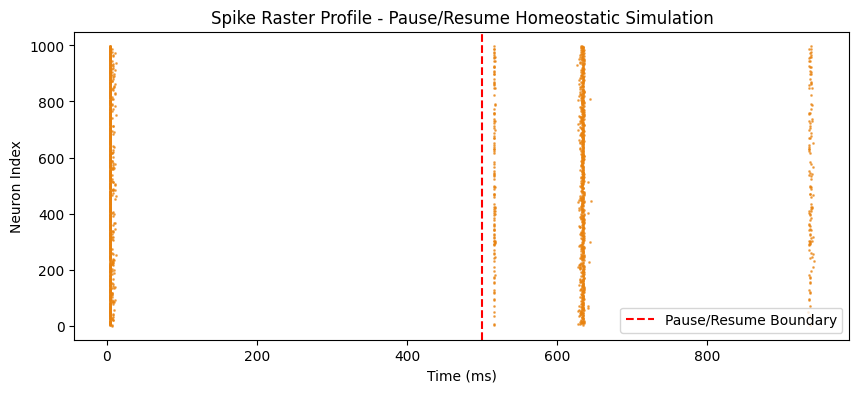

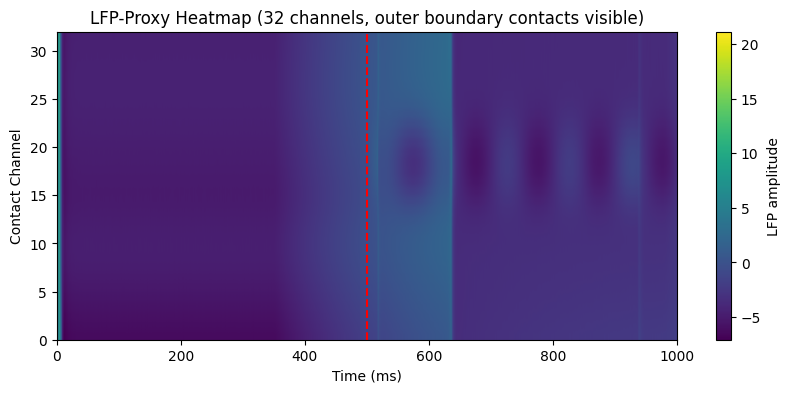

Saved: /Users/hamednejat/workspace/analysis/jaxfne/local/etude4/spectrolaminar_homeostatic_V1.png


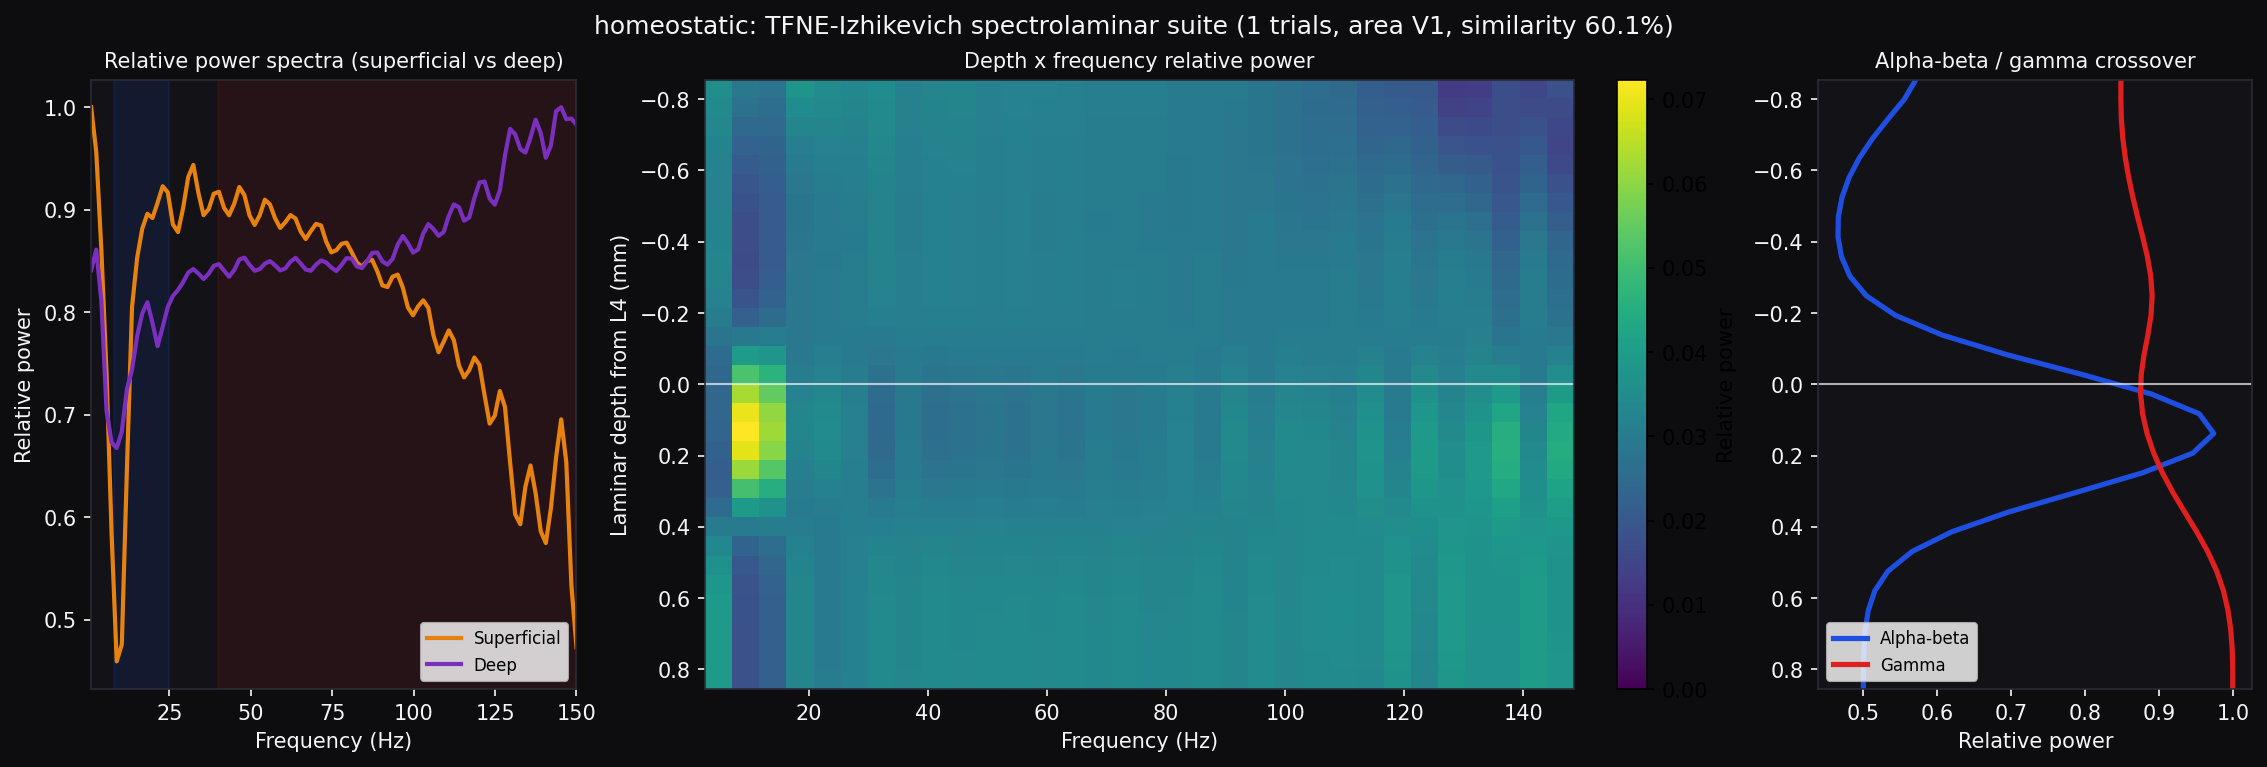

In [7]:
# 1. Plot Spike Raster
fig, ax = plt.subplots(figsize=(10, 4))
t_idx, n_idx = np.where(spikes_all > 0)
ax.scatter(t_idx * cfg.dt_ms, n_idx, s=1, color='#e8820e', alpha=0.6)
ax.axvline(500, color='red', linestyle='--', label='Pause/Resume Boundary')
ax.set_title("Spike Raster Profile - Pause/Resume Homeostatic Simulation")
ax.set_xlabel("Time (ms)")
ax.set_ylabel("Neuron Index")
ax.legend()
plt.show()

# 2. Plot LFP Heatmap
fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(lfp_contacts.T, aspect='auto', origin='lower', extent=[0, 1000, 0, 32], cmap='viridis')
ax.axvline(500, color='red', linestyle='--')
ax.set_title("LFP-Proxy Heatmap (32 channels, outer boundary contacts visible)")
ax.set_xlabel("Time (ms)")
ax.set_ylabel("Contact Channel")
fig.colorbar(im, label='LFP amplitude')
plt.show()

# 3. Spectrolaminar crossing evaluation
scores, specs = jtfne.tutorial_utils.summarize_spectrolaminar_similarity(
    trials, cfg, areas=("V1",), signal_key="lfp_contacts"
)

figs_spectro = jtfne.vis.spectrolaminar_suite_3panel(
    specs, model, cfg, stage="homeostatic", output_dir=cfg.output_dir, theme="dark"
)
plt.show()

## 8. Exporting JSON Manifests & Validation Checks

In [8]:
manifest_dict = cfg.to_manifest_dict()
metrics_dict = {
    "firing_rate_hz": float(spikes_all.sum() / (sim.n_neurons * 1.0)),
    "lfp_channels": 32,
    "simulation_interrupted_resume": True,
    "homeostasis_k_gain": float(sim.k_gain)
}
validation_dict = {
    "finite_spikes": bool(np.isfinite(spikes_all).all()),
    "finite_lfp": bool(np.isfinite(lfp_contacts).all()),
    "probe_out_of_bounds_test": bool(contacts_rel[0] < 0 and contacts_rel[-1] > 1)
}

paths = jtfne.tutorial_utils.export_tutorial_artifacts(
    cfg, manifest_dict=manifest_dict, metrics_dict=metrics_dict,
    validation_dict=validation_dict, output_dir=cfg.output_dir
)
for k, v in paths.items():
    print(f"Saved {k}: {v}")

Saved manifest_path: /Users/hamednejat/workspace/analysis/jaxfne/local/etude4/manifest.json
Saved metrics_path: /Users/hamednejat/workspace/analysis/jaxfne/local/etude4/metrics.json
Saved validation_report_path: /Users/hamednejat/workspace/analysis/jaxfne/local/etude4/validation_report.json
